In [1]:
import pandas as pd
import numpy as np

In [3]:
pip install vk_api pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 437.5 kB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [7]:
import vk_api
from datetime import datetime
from tqdm import tqdm
import time


# Мой токен
token = 'XXX'

vk_session = vk_api.VkApi(token=token)
vk = vk_session.get_api()

# группы которые мы отобрали
group_ids = [
    'singerbar.moscow',
    'karaokebarles',
    'fortepianokaraoke',
    'karaoke_moskow',
    'semenov_karaoke'
]

fields = (
    'sex,bdate,city,country,home_town,relation,'
    'occupation,career,universities,schools,personal,activities,'
    'interests,music,movies,tv,books,games,about,quotes,followers_count'
)

def calculate_age(bdate):
    try:
        birthdate = datetime.strptime(bdate, '%d.%m.%Y')
        today = datetime.now()
        age = today.year - birthdate.year - ((today.month, today.day) < (birthdate.month, birthdate.day))
        return age
    except:
        return None

users_data = []
collected_ids = set()

for group_id in group_ids:
    offset = 0
    batch_size = 500 
    

    group_info = vk.groups.getMembers(group_id=group_id)
    total_group_members = group_info['count']
    
    print("\nГруппа: ", group_id, ", участников: ", total_group_members)
    
    while offset < total_group_members and len(collected_ids) < 1000:
        
        members_batch = vk.groups.getMembers(group_id=group_id, offset=offset, count=batch_size)['items']
        offset += batch_size
        
        # Группы на одну тематику, поэтому хотим только уникальных человечков
        new_members = [m for m in members_batch if m not in collected_ids]
        
        
        # Пока берем тока 1000 потому что долго парсится, в финальном проекте спарсим всё
        if len(collected_ids) + len(new_members) > 1000:

            
            new_members = new_members[:1000 - len(collected_ids)]
        
        user_info = vk.users.get(user_ids=new_members, fields=fields)
        
        for user in tqdm(user_info, desc=f"обработка айди {group_id}"):

            
            user_id = user['id']
            try:
                groups = vk.groups.get(user_id=user_id, extended=1, fields='name', count=1000)
                user_groups = [group['name'] for group in groups['items']]
            except:
                user_groups = []
            
            data = {
                'source_group': group_id,
                'id': user_id,
                'first_name': user.get('first_name'),
                'last_name': user.get('last_name'),
                'sex': 'Женский' if user.get('sex') == 1 else 'Мужской' if user.get('sex') == 2 else 'Не указан',
                'age': calculate_age(user.get('bdate', '')),
                'city': user.get('city', {}).get('title'),
                'country': user.get('country', {}).get('title'),
                'home_town': user.get('home_town'),
                
                'relation': user.get('relation'),
                'occupation': user.get('occupation', {}).get('name'),
                'career': '; '.join([job.get('company', '') for job in user.get('career', [])]),
                'universities': '; '.join([uni.get('name', '') for uni in user.get('universities', [])]),
                
                'schools': '; '.join([school.get('name', '') for school in user.get('schools', [])]),
                'activities': user.get('activities'),
                'interests': user.get('interests'),
                'music': user.get('music'),
                'movies': user.get('movies'),
                
                'tv': user.get('tv'),
                'books': user.get('books'),
                'games': user.get('games'),
                'about': user.get('about'),
                'quotes': user.get('quotes'),
                'followers_count': user.get('followers_count'),
                'groups': '; '.join(user_groups[:20])
            }

            users_data.append(data)
            collected_ids.add(user_id)
            
            if len(collected_ids) >= 1000:
                break
            
            time.sleep(0.35) 
        
        if len(collected_ids) >= 1000:
            break

# чистим дубли
df = pd.DataFrame(users_data).drop_duplicates(subset=['id'])

df = df.head(1000)

# Finally)))
df.to_csv('karaoke_1draft.csv', index=False, encoding='utf-8-sig')



Группа:  singerbar.moscow , участников:  2045


обработка айди singerbar.moscow: 100%|█████████▉| 499/500 [09:43<00:01,  1.17s/it]



Группа:  karaokebarles , участников:  1419

Группа:  fortepianokaraoke , участников:  572

Группа:  karaoke_moskow , участников:  376

Группа:  semenov_karaoke , участников:  489


In [11]:
df.shape

(1000, 25)

In [13]:
df.head(5)

,source_group,id,first_name,last_name,sex,age,city,country,home_town,relation,...,interests,music,movies,tv,books,games,about,quotes,followers_count,groups
0,singerbar.moscow,7297,Lera,Grigoryeva,Женский,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,NaN,
1,singerbar.moscow,167662,Anton,Bulavkin,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,2941.0,НОВАЯ МУЗЫКА — Популярные Песни; VK Музыка; КИ...
2,singerbar.moscow,319200,Tatyana,Boyko,Женский,NaN,None,None,Москва,4.0,...,"Мистика, психология, философия, буддизм, Тибет...","Witch House, Hardcore, alternative rock, alter...","Butterfly effect, Трасса 60, Готика, Игры разу...",,"Макс Фрай ""Чужак"", ""Автостопом по галактике"", ...",,"Бывают моменты, когда ты готов отдать все ради...","Счастье – верить, когда не верится,\nИ дышать ...",2306.0,
3,singerbar.moscow,446819,Alexy,Sledopyt,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,119.0,
4,singerbar.moscow,461487,Oleg,Rezepov,Мужской,NaN,Moscow,None,None,NaN,...,None,None,None,None,None,None,None,None,568.0,


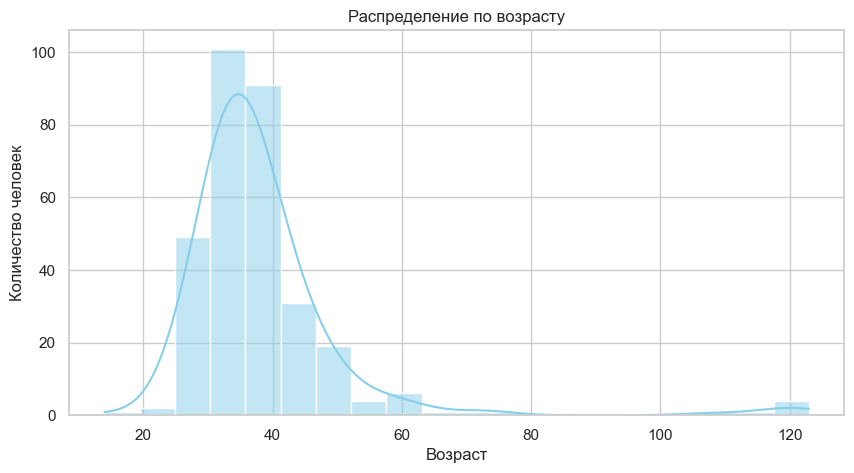

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Set2')


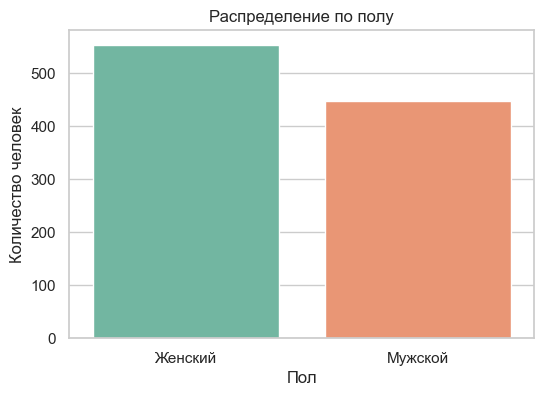

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='coolwarm')


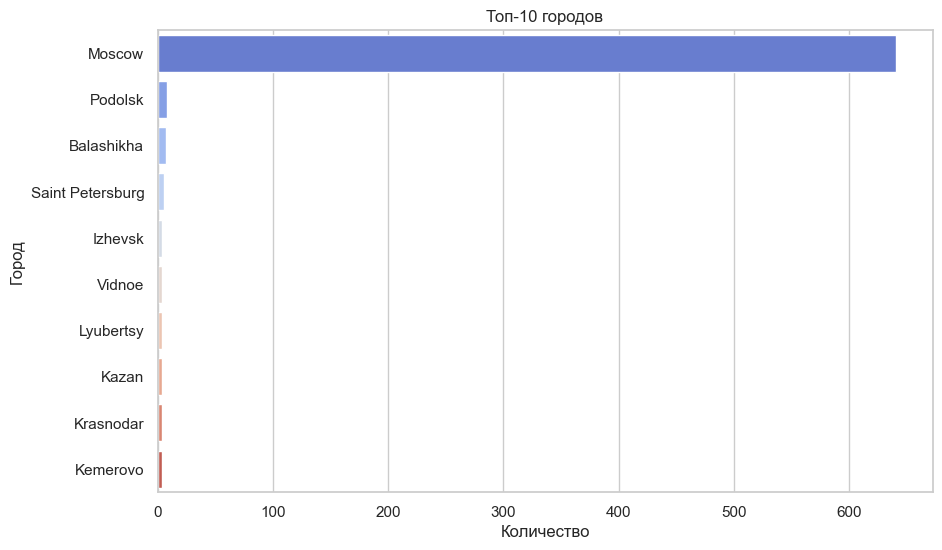

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='relation_status', data=df, order=df['relation_status'].value_counts().index, palette='viridis')


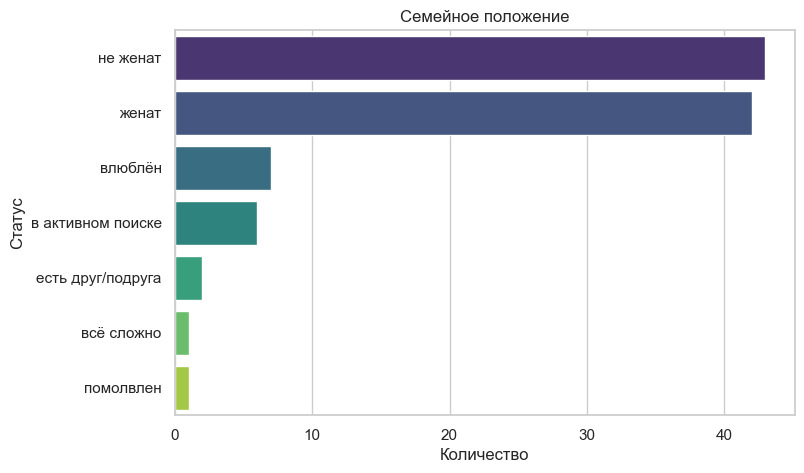

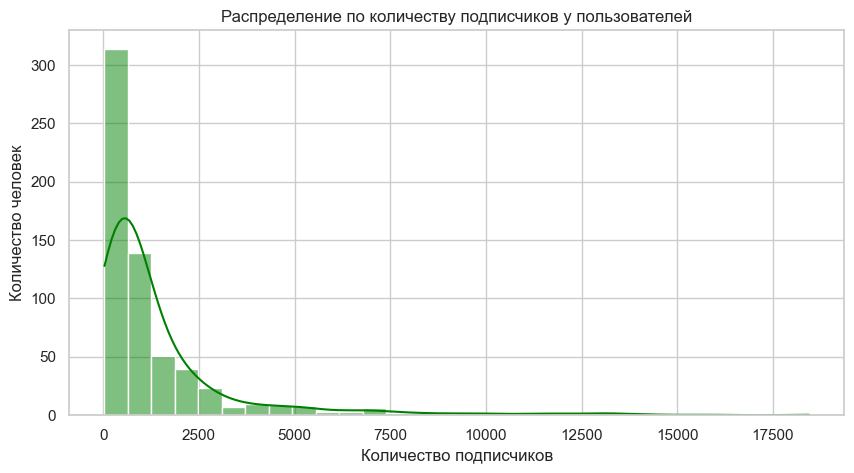

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='has_job', palette='pastel')


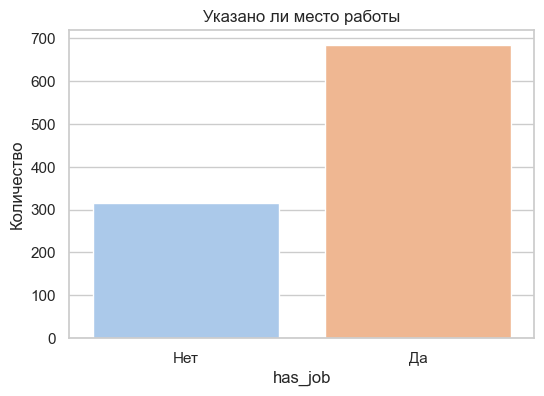

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Количество', y='Название', data=top_movies, palette='mako')


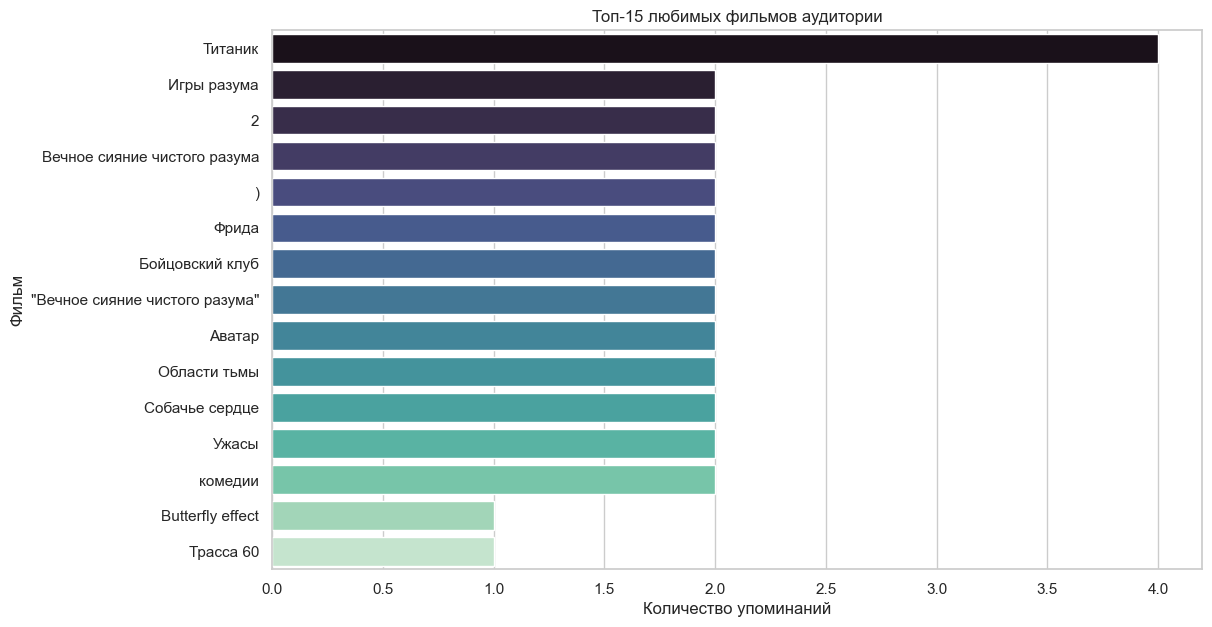

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Количество', y='Название', data=top_music, palette='flare')


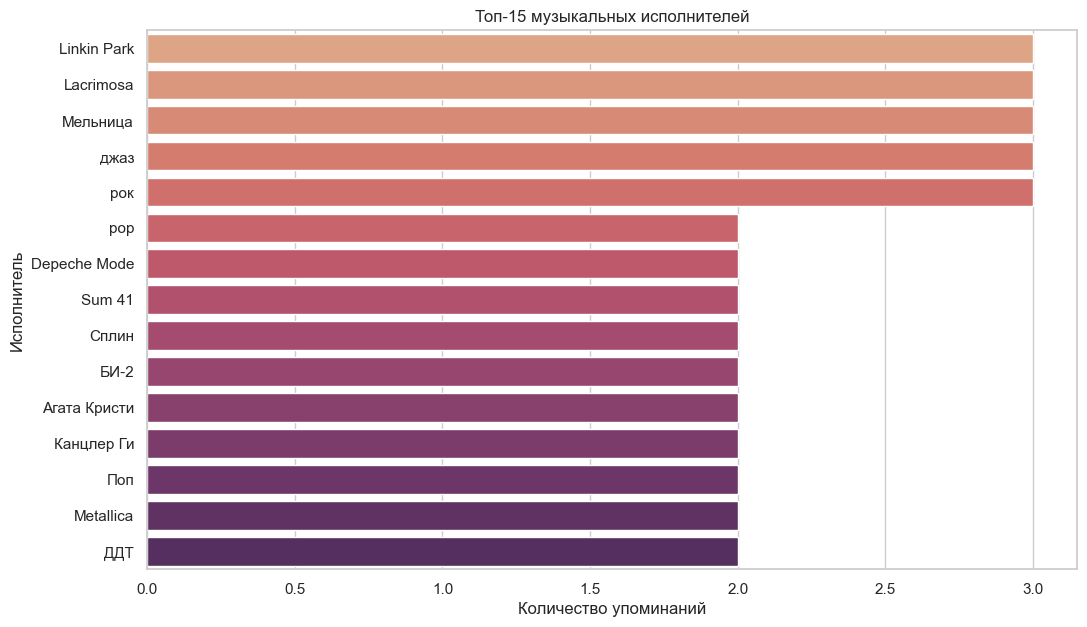

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Количество', y='Название', data=top_groups, palette='crest')
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129655 (\N{PINK HEART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


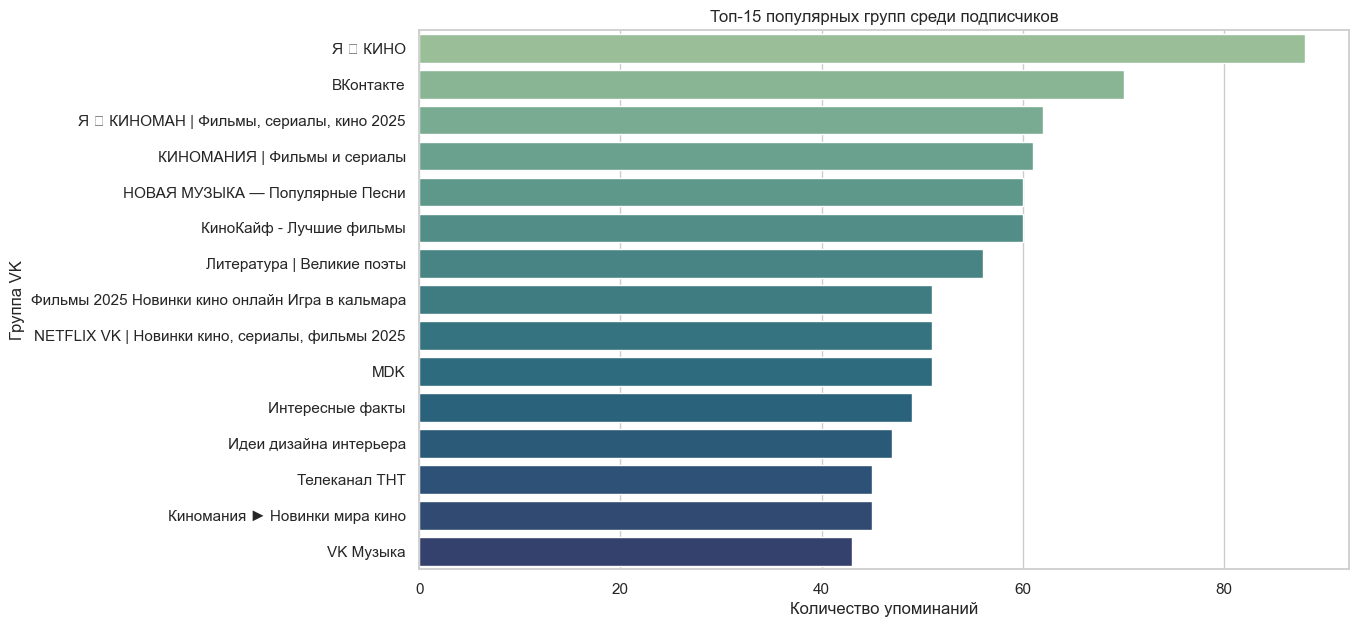

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Количество', y='Название', data=top_interests, palette='cubehelix')


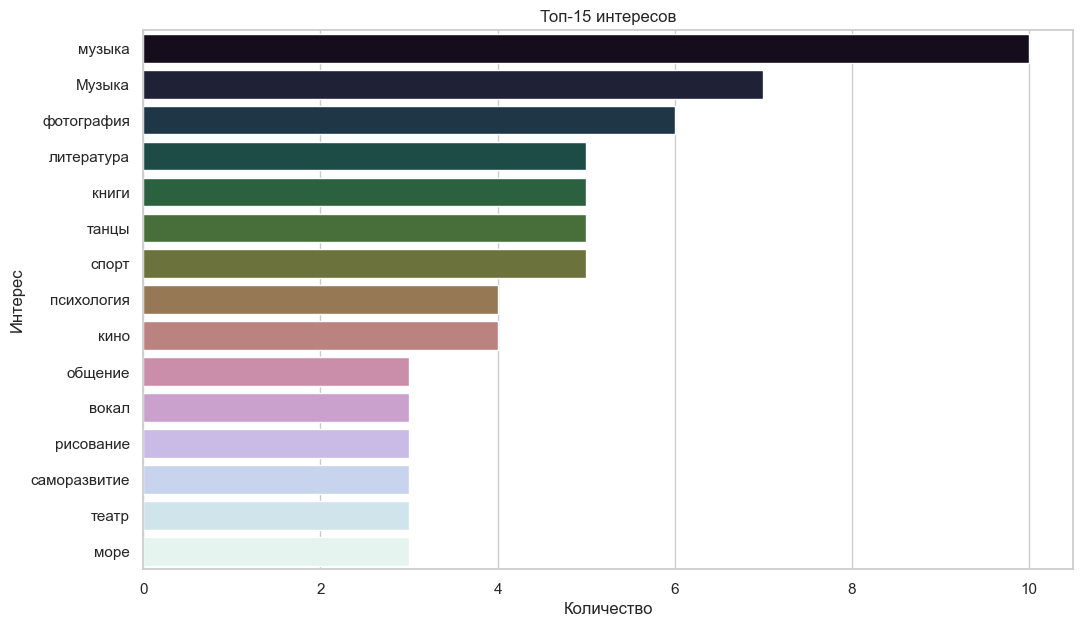

/var/folders/kd/t05z3w4d7nd87m1_q083y7f00000gq/T/ipykernel_48214/81222617.py:126: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Количество', y='Название', data=top_books, palette='Blues_r')


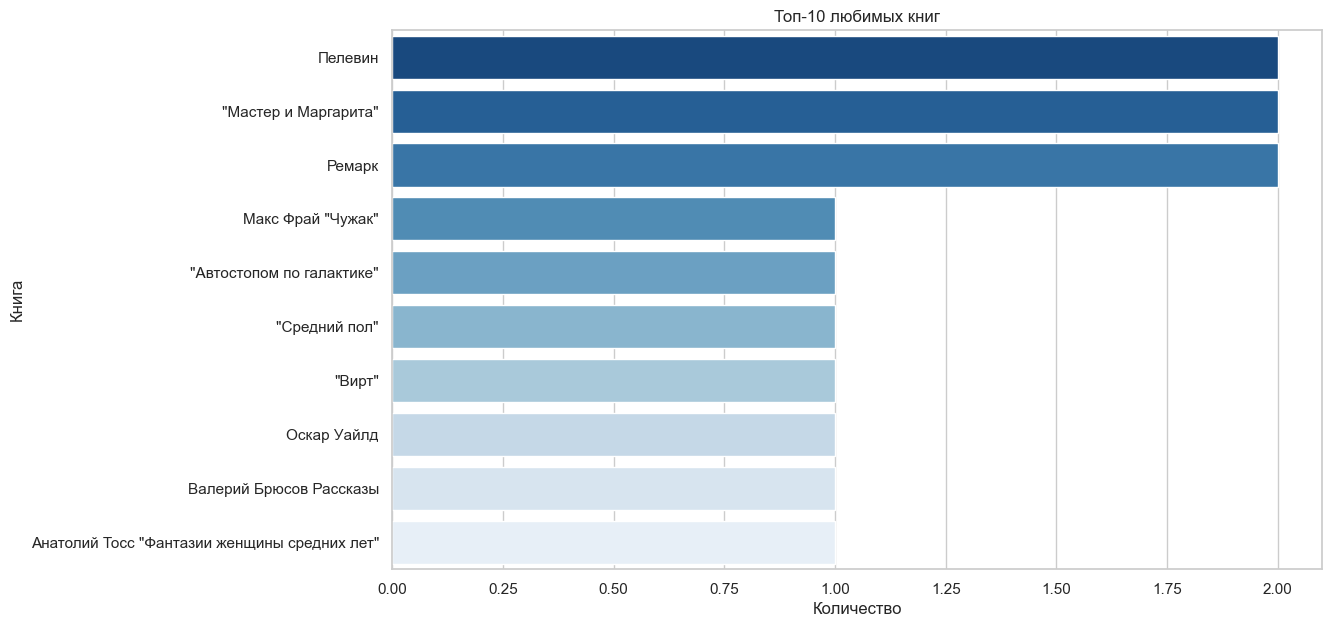

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import numpy as np

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


df = pd.read_csv('karaoke_1draft.csv')

# Посмотрим возраст и пол


plt.figure(figsize=(10,5))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='skyblue')

plt.title('Распределение по возрасту')

plt.xlabel('Возраст')
plt.ylabel('Количество человек')
plt.show()


plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sex', palette='Set2')
plt.title('Распределение по полу')

plt.xlabel('Пол')
plt.ylabel('Количество человек')

plt.show()

# Города (Потом оставим только Москву, я хорошо подобрала группы и большинство должны быть из москвы)
top_cities = df['city'].value_counts().head(10)

plt.figure(figsize=(10,6))

sns.barplot(x=top_cities.values, y=top_cities.index, palette='coolwarm')

plt.title('Топ-10 городов')

plt.xlabel('Количество')
plt.ylabel('Город')

plt.show()

# замужем \нет (потом может поможет нам для рекламы)
relation_dict = {1:'не женат',2:'есть друг/подруга',3:'помолвлен',4:'женат',5:'всё сложно',6:'в активном поиске',7:'влюблён',8:'гражд. брак'}

df['relation_status'] = df['relation'].map(relation_dict)


plt.figure(figsize=(8,5))
sns.countplot(y='relation_status', data=df, order=df['relation_status'].value_counts().index, palette='viridis')
plt.title('Семейное положение')

plt.xlabel('Количество')
plt.ylabel('Статус')
plt.show()

# Сколько у них подписчиков (раз есть инфа - пользуемся)
plt.figure(figsize=(10,5))
sns.histplot(df['followers_count'].dropna(), bins=30, kde=True, color='green')


plt.title('Распределение по количеству подписчиков у пользователей')

plt.xlabel('Количество подписчиков')
plt.ylabel('Количество человек')
plt.show()

# Работа
df['has_job'] = df['occupation'].notnull()
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='has_job', palette='pastel')
plt.title('Указано ли место работы')

plt.xticks([0,1], ['Нет','Да'])

plt.ylabel('Количество')

plt.show()


import re

# любимые фильмы
def get_top_movies(series, top_n=15):
    items = series.dropna().apply(lambda x: re.split(r'[;,\.]', x))
    flat_items = [item.strip() for sublist in items for item in sublist if item.strip()]
    return pd.DataFrame(Counter(flat_items).most_common(top_n), columns=['Название', 'Количество'])

def get_top_items(series, delimiters, top_n=15):
    pattern = '|'.join(map(re.escape, delimiters))
    items = series.dropna().apply(lambda x: re.split(pattern, x))
    flat_items = [item.strip() for sublist in items for item in sublist if item.strip()]
    return pd.DataFrame(Counter(flat_items).most_common(top_n), columns=['Название', 'Количество'])


# Топ-15 фильмов
top_movies = get_top_movies(df['movies'], top_n=15)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_movies, palette='mako')
plt.title('Топ-15 любимых фильмов аудитории')
plt.xlabel('Количество упоминаний')
plt.ylabel('Фильм')
plt.show()


# любимая музыка
top_music = get_top_items(df['music'], ',', top_n=15)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_music, palette='flare')
plt.title('Топ-15 музыкальных исполнителей')
plt.xlabel('Количество упоминаний')
plt.ylabel('Исполнитель')
plt.show()

# их группы
top_groups = get_top_items(df['groups'], ';', top_n=15)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_groups, palette='crest')
plt.title('Топ-15 популярных групп среди подписчиков')
plt.xlabel('Количество упоминаний')
plt.ylabel('Группа VK')
plt.show()

#интересы
top_interests = get_top_items(df['interests'], ',', top_n=15)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_interests, palette='cubehelix')
plt.title('Топ-15 интересов')
plt.xlabel('Количество')
plt.ylabel('Интерес')
plt.show()

#книги
top_books = get_top_items(df['books'], ',', top_n=10)

plt.figure(figsize=(12,7))
sns.barplot(x='Количество', y='Название', data=top_books, palette='Blues_r')
plt.title('Топ-10 любимых книг')
plt.xlabel('Количество')
plt.ylabel('Книга')
plt.show()
